In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
#import jdatetime

In [2]:
path = r'G:\.shortcut-targets-by-id\1RZJdNpCfbMt2SB_kfWsxQgOk5LeuV7lw\Divar Dataset\Divar.csv'
divar = pd.read_csv(path)
divar.head()

C:\Users\DANA-RAYANEH\AppData\Local\Temp\ipykernel_9092\1020264682.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  divar = pd.read_csv(path)


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
file_path = r'G:\.shortcut-targets-by-id\1u93J-JGxtx7vOpkuufdsEGMvt3u8paey\divar_analysis\preprocessing_output_v4.parquet'

data = pd.read_parquet(file_path)
data.head()

,Unnamed: 0,city_slug,description,title,rent_mode,rent_value,price_mode,price_value,credit_mode,credit_value,...,land_size_was_missing,floor_was_missing,rooms_count_was_missing,total_floors_count_was_missing,unit_per_floor_was_missing,construction_year_was_missing,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing
0,0,karaj,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,<NA>,NaN,<NA>,NaN,<NA>,NaN,...,1,1,0,1,1,1,9.0,1,1,1
1,1,tehran,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,<NA>,NaN,مقطوع,8.500000e+09,<NA>,NaN,...,1,0,0,1,1,0,20.0,1,1,1
2,2,tehran,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,<NA>,NaN,مقطوع,750000000.0,...,1,0,0,1,1,0,3.0,0,1,1
3,3,tehran,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,<NA>,NaN,مقطوع,950000000.0,...,1,0,0,1,1,0,4.0,1,1,1
4,4,mashhad,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,<NA>,NaN,مقطوع,5.750000e+09,<NA>,NaN,...,1,0,0,0,1,0,1.0,1,0,1


In [4]:
data.columns

Index(['Unnamed: 0', 'city_slug', 'description', 'title', 'rent_mode',
       'rent_value', 'price_mode', 'price_value', 'credit_mode',
       'credit_value', 'land_size', 'building_size', 'deed_type',
       'has_business_deed', 'floor', 'rooms_count', 'total_floors_count',
       'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse',
       'has_parking', 'construction_year', 'is_rebuilt', 'has_water',
       'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'location_latitude',
       'location_longitude', 'is_negotiable', 'is_transformable',
       'is_full_mortgage', 'equivalent_full_credit', 'weekend_price_ratio',
       'special_day_price_ratio', 'is_rent_credit_convertible',
       'allows_single_tenant', 'log_price_value', 'log_credit_value',
       'log_rent_valu

In [5]:
data['neighborhood_slug'] = divar['neighborhood_slug']

In [6]:
data['for_rent?'] = data['deal_type_rent'] | data['deal_type_temporary_rent']
data['for_rent?']

0         1
1         0
2         1
3         1
4         0
         ..
999995    0
999996    1
999997    0
999998    1
999999    1
Name: for_rent?, Length: 1000000, dtype: int64

<div dir="rtl">
سوال 6 آمار توصیفی:
ترند میانگین قیمت اجاره بر حسب ماه‌های قرار گرفتن آگهی‌ها رسم کنید.(دقت کنید که ماه‌ها باید به تاریخ شمسی و خوانا باشند)
</div>


In [7]:
data['month']

0          8
1          5
2         10
3          6
4          5
          ..
999995     7
999996     7
999997    11
999998     9
999999     8
Name: month, Length: 1000000, dtype: int32

In [8]:
print(data['for_rent?'].dtype)

int64


In [9]:
month_map = {
    4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6,
    10: 7, 11: 8, 12: 9, 1: 10, 2: 11, 3: 12
}

data['jalali_month'] = data['month'].map(month_map)

rent_df = data[data['for_rent?'].astype(bool)]
monthly_avg = (
    rent_df.groupby('jalali_month')['rent_value']
    .mean()
    .reindex(range(1, 13))
    .reset_index()
)
monthly_avg['rent_value'] = monthly_avg['rent_value'] / 1000000
monthly_avg

,jalali_month,rent_value
0,1,29.642535
1,2,20.887422
2,3,16.562998
3,4,16.646343
4,5,16.199921
5,6,16.878983
6,7,18.231563
7,8,19.503107
8,9,19.610975
9,10,30.141094


😭😭😭😭😭😭😭?

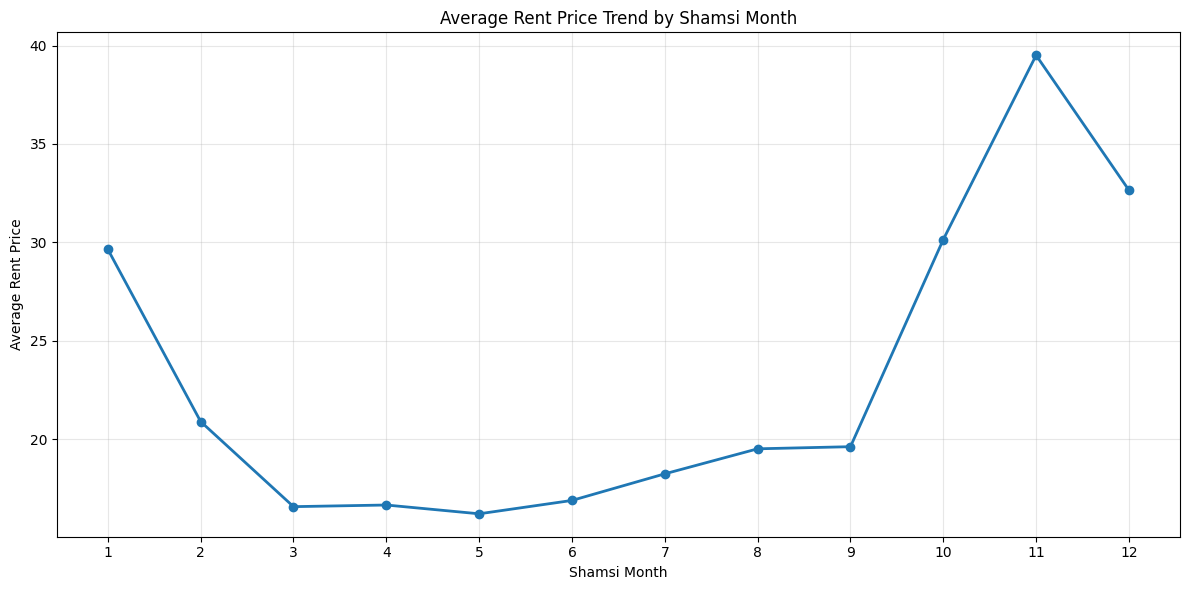

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['jalali_month'], monthly_avg['rent_value'], marker='o', linewidth=2)
plt.xticks(monthly_avg['jalali_month'])
plt.xlabel('Shamsi Month')
plt.ylabel('Average Rent Price')
plt.title('Average Rent Price Trend by Shamsi Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
data.drop(columns='for_rent?', inplace = True)

<div dir="rtl">
سوال 9 آمار توصیفی: 
میخواهیم بررسی کنیم خانه‌هایی که دارای بالکن، آسانسور، نگهبان، باربیکیو و استخر هستند عمدتا در کدام مناطق قرار دارند. با نمودار مناسب این موضوع را نشان دهید.
</div>

In [12]:
amenity_cols = ['has_balcony', 'has_elevator', 'has_security_guard', 'has_barbecue', 'has_pool']

mask = data[amenity_cols].eq(True).all(axis=1)
filtered = data[mask]

print(f'تعداد آگهی‌های واجد همه‌ی امکانات: {len(filtered)}')

تعداد آگهی‌های واجد همه‌ی امکانات: 0


😭😭😭😭😭😭😭😭😭

In [13]:
data['amenity_score'] = data[amenity_cols].fillna(False).astype(bool).sum(axis=1)
filtered = data[data['amenity_score'] > 3]
print(f'تعداد آگهی‌های واجد شرط: {len(filtered)}')

تعداد آگهی‌های واجد شرط: 24799


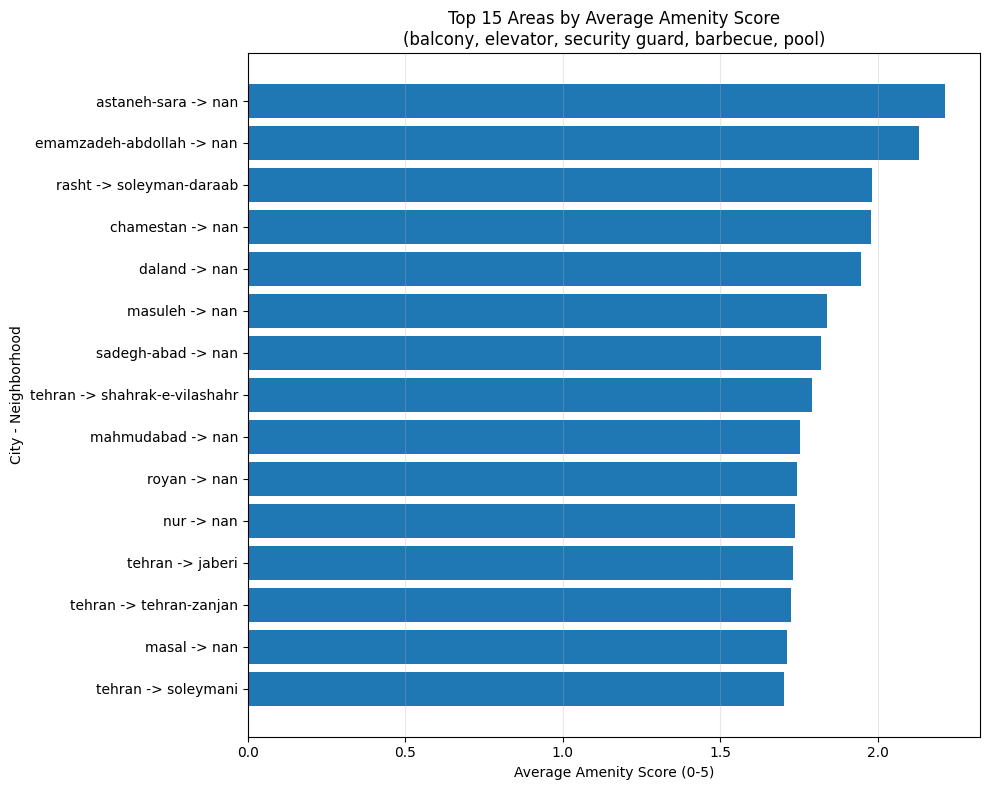

In [14]:
data['amenity_score'] = data[amenity_cols].fillna(False).astype(bool).sum(axis=1)

data['city_neighborhood'] = data['city_slug'].astype(str) + ' -> ' + data['neighborhood_slug'].astype(str)
area_stats = data.groupby('city_neighborhood')['amenity_score'].agg(['mean', 'count'])

min_listings = 10
reliable_areas = area_stats[area_stats['count'] >= min_listings]

top_n = 15
top_areas = reliable_areas.sort_values('mean', ascending=False).head(top_n).sort_values('mean')

plt.figure(figsize=(10, 8))
plt.barh(top_areas.index, top_areas['mean'])
plt.xlabel('Average Amenity Score (0-5)')
plt.ylabel('City - Neighborhood')
plt.title(f'Top {top_n} Areas by Average Amenity Score\n(balcony, elevator, security guard, barbecue, pool)')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">
سوال 4 آزمون فرض:
در دسته‌بندی امکانات موجود در آگهی‌ها می‌توانیم آنها را به دو دسته‌ی امکانات لاکچری(استخر، باربیکیو، سونا، جکوزی) و امکانات غیر لاکچری تقسیم کنیم. فرضیه‌ی ما این است که میانگین مبلغ قیمت برای وجود ویژگی‌های لاکچری افزایش چشم‌گیری دارد. اما آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد؟

</div>

<div dir="rtl">
فرض سوال: میانگین قیمت آگهی‌هایی که امکانات لاکچری دارند از میانگین قیمت آگهی‌هایی که امکانات لاکچری ندارند بیشتر است.<br>
فرض 0: μ قیمت لاکچری ≤ μ قیمت غیر لاکچری<br>
فرض 1: μ قیمت لاکچری > μ قیمت غیر لاکچری
</div>

In [15]:
data['luxury'] = data['has_suana_jacuzzi'] | data['PreP_has_barbecue'] | data['PreP_has_pool']
data['luxury']

0          True
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Name: luxury, Length: 1000000, dtype: bool

In [16]:
is_luxury = data[
    (data['luxury']) & 
    (data['price_value'].notna())
]
is_luxury.head()

,Unnamed: 0,city_slug,description,title,rent_mode,rent_value,price_mode,price_value,credit_mode,credit_value,...,construction_year_was_missing,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing,neighborhood_slug,jalali_month,amenity_score,city_neighborhood,luxury
32,32,mashhad,تک واحدی \nفول کامل \nآشپزخانه کثیف \nتراس \nک...,آپارتمان 170 متری /صفر کلیدنخورده/امام رضا 49,<NA>,NaN,مقطوع,1.000000e+10,<NA>,NaN,...,0,1.0,1,1,1,emamreza,4,1,mashhad -> emamreza,True
78,78,arak,یک قطعه باغ به متراژ ۴۲۰۰ متر که ۱۲۰۰ مهران در...,باغ به متراژ ۴۲۰۰ متر,<NA>,NaN,مقطوع,1.700000e+09,<NA>,NaN,...,1,9.0,1,1,1,NaN,2,0,arak -> nan,True
129,129,khorramabad,با سلام زمین باغی ۱۸کیلومتر فاصله با شهر.جاده ...,زمین مخصوص خانه باغ همراه با سند تک برگ,<NA>,NaN,مقطوع,1.111111e+09,<NA>,NaN,...,1,9.0,1,1,1,NaN,5,0,khorramabad -> nan,True
176,176,mashhad,۱۰۰۰ متر دور دیوار . داخل مجموعه گلها . واقع د...,باغ دور دیوار به مساحت ۱۰۰۰ متر در جاده دولت آباد,<NA>,NaN,مقطوع,1.400000e+09,<NA>,NaN,...,1,9.0,1,1,1,eqbal,4,0,mashhad -> eqbal,True
212,212,chamestan,✅مدرن استخر دار ( کد ۹۸۱)\n✅180 زمین\n ✅100متر...,ویلا مدرن استخردار/ آتشکده داخل حیاط,<NA>,NaN,مقطوع,2.550000e+09,<NA>,NaN,...,0,1.0,0,0,1,NaN,8,4,chamestan -> nan,True


In [17]:
is_not_luxury = data[
    (~data['luxury']) & 
    (data['price_value'].notna())
]
is_not_luxury.head()

,Unnamed: 0,city_slug,description,title,rent_mode,rent_value,price_mode,price_value,credit_mode,credit_value,...,construction_year_was_missing,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing,neighborhood_slug,jalali_month,amenity_score,city_neighborhood,luxury
1,1,tehran,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,<NA>,NaN,مقطوع,8.500000e+09,<NA>,NaN,...,0,20.0,1,1,1,gholhak,2,1,tehran -> gholhak,False
4,4,mashhad,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,<NA>,NaN,مقطوع,5.750000e+09,<NA>,NaN,...,0,1.0,1,0,1,emamreza,2,2,mashhad -> emamreza,False
7,7,tehran,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,<NA>,NaN,مقطوع,8.700000e+09,<NA>,NaN,...,0,11.0,1,1,1,dardasht,6,1,tehran -> dardasht,False
8,8,mahdasht-city,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,<NA>,NaN,مقطوع,6.500000e+08,<NA>,NaN,...,0,8.0,0,0,1,NaN,3,2,mahdasht-city -> nan,False
9,9,mashhad,اول رسالت فرد نزدیک به حاشیه فرامرز .. ساکنین...,متراژ ۸۰ متر فرامرز نزدیک حاشیه,<NA>,NaN,مقطوع,3.000000e+09,<NA>,NaN,...,0,17.0,0,1,1,faramarzabbasi,7,2,mashhad -> faramarzabbasi,False


In [18]:
shapiro_stat1, shapiro_p1 = stats.shapiro(is_luxury['price_value'].astype('int'))
shapiro_stat2, shapiro_p2 = stats.shapiro(is_not_luxury['price_value'].astype('int'))

print("Shapiro-Wilk Normality Test:")
print(f"is luxury - p-value: {shapiro_p1:.10f}")
print(f"is not luxury - p-value: {shapiro_p2:.100f}")

Shapiro-Wilk Normality Test:
is luxury - p-value: 0.0000000000
is not luxury - p-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


c:\Users\DANA-RAYANEH\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 29178.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\DANA-RAYANEH\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 525982.
  res = hypotest_fun_out(*samples, **kwds)


In [19]:
print(shapiro_p1 == 0.0)
print(len(is_luxury))

False
29178


In [20]:
print(repr(shapiro_p1))

5.671678028796508e-122


<div dir="rtl">
هر دو گروه توزیع نرمال ندارن پس برای مقایسه‌ی میانگین قیمت بین آگهی‌های لاکچری و غیرلاکچری باید از تست ناپارامتریک Mann-Whitney U استفاده شه، نه t-test مستقل.
</div>

In [21]:
u_stat, p_value = stats.mannwhitneyu(is_luxury['price_value'], is_not_luxury['price_value'], alternative='greater')

print(f"U statistic: {u_stat}")
print(f"p-value: {p_value}")
print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

U statistic: 9644289143.5
p-value: 0.0
Reject H0


<div dir="rtl">
با توجه به اینکه U statistic مقدار میلیاردی داره و P بسیار نزدیک به 0 هست، فرض 0 رد میشه.
به این معنی که شواهد آماری قوی وجود داره که میانگین قیمت آگهی‌های لاکچری به طور معناداری از غیرلاکچری بیشتره
</div>